In [6]:
import torch
from torch import nn
from torch.nn import functional as F
from torchvision import transforms
from matplotlib import pyplot as plt
from matplotlib import cm as cm
from PIL import Image
import cv2 as cv
import numpy as np

In [10]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [3]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.feature_maps = None
        self.gradients = None
        
        self.hook_handles = []
        
        def forward_hook(module, input, output):
            self.feature_maps = output.detach()
        
        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()
            
        for name, module in model.named_modules():
            if name == target_layer:
                self.hook_handles.append(module.register_forward_hook(forward_hook))
                self.hook_handles.append(module.register_backward_hook(backward_hook))
                break
    
    def __call__(self, x, class_idx= None):
        self.model.eval()
        x.requires_grad_()
        
        output = self.model(x)
        if class_idx is None:
            class_idx = torch.argmax(output, dim= 1).item()
            
        self.model.zero_grad()
        
        # batch_size = output.shape[0]
        target = output[0, class_idx]
        target.backward()
        
        if self.gradients is None:
            print('警告: 梯度为None，返回零热力图')
            return torch.zeros(x.shape[1], x.shape[2]).cpu().numpy()
        
        weights = F.adaptive_avg_pool2d(self.gradients, 1)
        weights = weights.squeeze(-1).squeeze(-1)
        
        cam = torch.sum(weights[:, :, None, None] * self.feature_maps, dim= 1)
        cam = F.relu(cam)
        
        # if cam.dim() == 3:
        #     cam = cam.unsqueeze(1)
        
        cam = F.interpolate(
            cam.unsqueeze(0),
            size= (x.shape[2], x.shape[3]),
            mode= 'bilinear',
            align_corners= False
        ).squeeze()
        
        cam_min = cam.min()
        cam_max = cam.max()
        if cam_max - cam_min > 1e-8:
            cam = (cam - cam_min) / (cam_max - cam_min)
        else:
            cam = torch.zeros_like(cam)
        return cam.detach().cpu().numpy()
    
    def remove_hooks(self):
        for handle in self.hook_handles:
            handle.remove()

In [4]:
def get_model_layers(model):
    layers = []
    for name, module in model.named_modules():
        layers.append(name)
    return layers

In [8]:
from models.MobileNetV2 import MobileNetV2
model = MobileNetV2(in_ch= 1)
layers = get_model_layers(model)
# layers

In [11]:
model.load_state_dict(torch.load('save_models/mobV2/MobileNetV2_1C_MD_42.pth'))
model.to(device)
model.eval()
print('model loaded')

model loaded


In [17]:
target_img = "C:/Users/Administrator/Desktop/datas/test_data_black/5/mn5_cnn2_mbpp0_2025-09-21-15_26_01.png"
# traget_label = torch.tensor([5])

In [18]:
def preprocess_image(img_paths, in_channels):
    """将图像转换为模型输入格式（归一化、转张量）"""
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize((0.1307, ), (0.3081, ))
    ])
    if in_channels == 3: img = Image.open(img_paths).convert('RGB')
    else: img = Image.open(img_paths).convert('L')
    img_tensor = transform(img).unsqueeze(0).to(device)
    return img, img_tensor

e:\Anaconda3_2020\envs\pythonProject\lib\site-packages\torch\nn\modules\module.py:1842: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_23912\2281674212.py:31: UserWarning: Glyph 31532 (\N{CJK UNIFIED IDEOGRAPH-7B2C}) missing from font(s) DejaVu Sans.
  plt.draw()  # 刷新图像
C:\Users\Administrator\AppData\Local\Temp\ipykernel_23912\2281674212.py:31: UserWarning: Glyph 23618 (\N{CJK UNIFIED IDEOGRAPH-5C42}) missing from font(s) DejaVu Sans.
  plt.draw()  # 刷新图像
C:\Users\Administrator\AppData\Local\Temp\ipykernel_23912\2281674212.py:31: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from font(s) DejaVu Sans.
  plt.draw()  # 刷新图像
C:\Users\Adminis

正在展示第2层，1000秒后自动切换（按任意键提前切换）...


KeyboardInterrupt: 

e:\Anaconda3_2020\envs\pythonProject\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31532 (\N{CJK UNIFIED IDEOGRAPH-7B2C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\Anaconda3_2020\envs\pythonProject\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23618 (\N{CJK UNIFIED IDEOGRAPH-5C42}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\Anaconda3_2020\envs\pythonProject\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\Anaconda3_2020\envs\pythonProject\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
e:\Anaconda3_2020\envs\pythonProject\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27599 (\N{

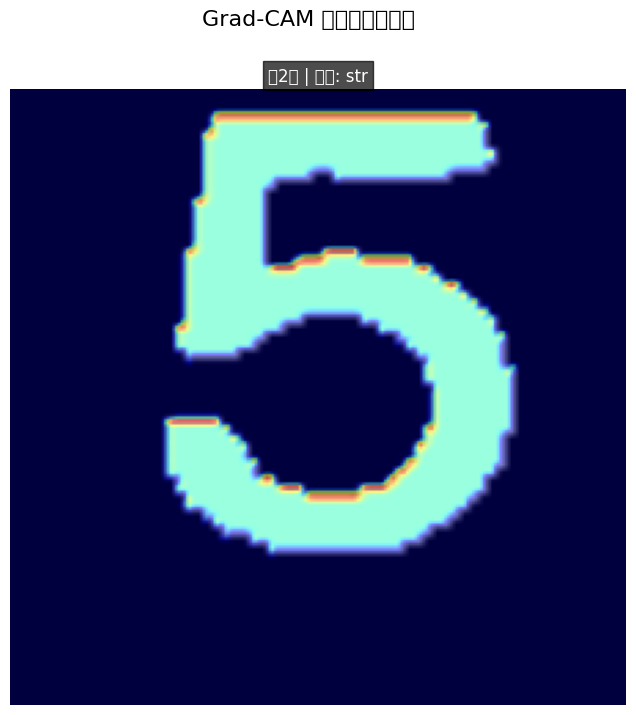

In [20]:
width, height = 224, 224
frame_duration=1000
# 创建显示窗口
# 初始化matplotlib交互式模式
plt.ion()  # 开启交互式显示
fig, ax = plt.subplots(figsize=(8, 8))
fig.suptitle('Grad-CAM 每层热力图展示', fontsize=16)

heatmaps = []
for i, layer in enumerate(layers):
    if i == 0: continue
    try:
        grad_cam = GradCAM(model, layer)
        img, img_tensor = preprocess_image(target_img, 1)
        img_np = np.array(img.convert('RGB'))
        heatmap = grad_cam(img_tensor)
        # 热力图上色（jet色系）
        heatmap = cm.jet(heatmap)[:, :, :3]  # 去掉alpha通道，保留RGB
        heatmap = (heatmap * 255).astype(np.uint8)
        
        # 融合原图与热力图（权重可调整）
        blended = (img_np * 0.5 + heatmap * 0.5).astype(np.uint8)
        
        # 更新图像显示
        ax.clear()
        ax.imshow(blended)
        # 添加层信息标注
        layer_info = f'第{i+1}层 | 类型: {layer.__class__.__name__}'
        ax.set_title(layer_info, fontsize=12, color='white', bbox=dict(facecolor='black', alpha=0.7))
        ax.axis('off')  # 隐藏坐标轴
        plt.draw()  # 刷新图像
        
        # 控制显示时长，按任意键可提前切换到下一层
        print(f"正在展示第{i+1}层，{frame_duration}秒后自动切换（按任意键提前切换）...")
        plt.waitforbuttonpress(timeout=frame_duration)
    except Exception as e:
        print(f"layerName:{layer},处理失败: {e}")
    finally:
        if 'heatmap' in locals():
            del heatmap
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    grad_cam.remove_hooks()
plt.ioff()
plt.close()